# **5. Transformer**

> 이번 실습에서는 NLP 분야에서 가장 많이 사용되고 있으며, Computer Vision 분야 등 다양한 분야에서도 활용되고 있는 **Transformer** 모델에 대해 학습한다.

>Transformer 모델은 이전 단원에서 학습한 attention 모듈을 발전시킨 Multi-head Attention으로 구성된 모델 구조이다.
>
>Multi-head Attention에 대해 먼저 학습해보자.


> ## 0. Setup
> 필요한 package를 import한다.

In [1]:
from torch import nn
from torch.nn import functional as F
from tqdm import tqdm
import matplotlib.pyplot as plt

import torch
import math
import numpy as np
import os

### **예시 데이터 생성**

> Multi-head Attention 구현에 활용하기 위한 예시 데이터를 만들어보자.

In [2]:
pad_id = 0
vocab_size = 100

data = [
  [62, 13, 47, 39, 78, 33, 56, 13],
  [60, 96, 51, 32, 90],
  [35, 45, 48, 65, 91, 99, 92, 10, 3, 21],
  [66, 88, 98, 47],
  [77, 65, 51, 77, 19, 15, 35, 19, 23]
]

>이전 단원에서 다뤘던 것처럼, 모든 문장의 길이가 같아지도록 0 token을 padding으로 추가한다.

In [3]:
def padding(data):

  # 모든 문장 들 중 len 함수(길이) 기준으로 가장 긴 문장을 선택하고,
  # 그 문장의 길이를 max_len 에 저장
  max_len = len(max(data, key=len))

  print(f"Maximum sequence length: {max_len}")

  for i, seq in enumerate(tqdm(data)):
    if len(seq) < max_len:

      # max_len과 len(seq) 차이 만큼
      # seq 뒷 부분에 [pad_id] 를 추가
      data[i] = seq + [pad_id] * (max_len - len(seq))

  return data, max_len

```python
max(iterable, key=f)
```

는

> iterable의 각 원소에 대해 `f(원소)`를 계산한 뒤,
>
> 그 값이 가장 큰 원소를 반환한다는 의미

In [4]:
data, max_len = padding(data)

Maximum sequence length: 10


100%|██████████| 5/5 [00:00<00:00, 35726.61it/s]


In [5]:
data

[[62, 13, 47, 39, 78, 33, 56, 13, 0, 0],
 [60, 96, 51, 32, 90, 0, 0, 0, 0, 0],
 [35, 45, 48, 65, 91, 99, 92, 10, 3, 21],
 [66, 88, 98, 47, 0, 0, 0, 0, 0, 0],
 [77, 65, 51, 77, 19, 15, 35, 19, 23, 0]]

In [7]:
# seq + [pad_id] * (max_len - len(seq)) 에서
# 왜 pad_id가 아니라 [pad_id]를 더하는지 확인

data[0] + pad_id

TypeError: can only concatenate list (not "int") to list

In [8]:
data[0] + [pad_id]

[62, 13, 47, 39, 78, 33, 56, 13, 0, 0, 0]

### **Hyperparameter 세팅 및 embedding**

> Multi-head Attention을 위한 Hyper-parameter를 설정한다.
>
>또 Embedding layer를 선언한 후 위에서 만든 예시 데이터의 embedding을 구한다.
>
>Embedding layer는 `nn.Embedding(vocab_size, d_model)`로 선언할 수 있으며, **token_id 를 입력값으로 받아 그에 해당하는 embedding vector를 반환하는 일종의 lookup table이다.**
>
>**반환되는 embedding vector도 일반적인 neural network layer의 parameter처럼 학습**되기 때문에 학습 가능한 모델의 일부분으로서 *layer*라는 표현을 사용한다.

In [9]:
d_model = 512  # model의 hidden size
num_heads = 8  # head의 개수

In [10]:
# [0, vocab_size - 1] 내의 id(정수)로 조회하면 d_model 사이즈의 벡터를 반환
# 단, nn.Embedding의 파라미터는(vocab_size 개 만큼의 d_model 사이즈의 벡터들) Gradient Descent에 의해 학습이 됨
embedding = nn.Embedding(vocab_size, d_model)


'''
batch는 embedding에서 조회를 해야 하는 정수이므로 LongTensor
batch_emb는 위 정수에 의해 조회된 d_model 사이즈 만큼의 벡터들의 모임(batch 개수만큼)
'''

# B: batch size, L: maximum sequence length
batch = torch.LongTensor(data)  # (B, L)
batch_emb = embedding(batch)  # (B, L, d_model)

In [11]:
'''
B는 data의 개수인 5
L은 data 중에서 가장 긴 요소의 길이인 10
d_model은 512로 지정
'''


print(f'batch_emb shape: {batch_emb.shape}')

batch_emb shape: torch.Size([5, 10, 512])


## 1. Multi-head Attention

> 먼저 Multi-head attention 코드를 구현한다.
>
>이전 단원에서 다뤘던 attention은 head가 한 개인 single-head Attention이고, head의 개수를 늘려서 multi-head Attention을 구현할 수 있다.
>

### **Linear transformation & 여러 head로 나누기**

> Multi-head attention 내에서 쓰이는 linear transformation matrix들을 정의한다.

In [12]:
'''
attention에서 내적으로 유사도를 구할 때,
자기 자신과의 내적은 항상 가장 높기 때문에
주변 context의 정보를 가져오지 못함

그래서 Q, K, V 행렬을 통해 변환 후 q와 k간의 내적을 구함

Query : context embedding을 구하고 싶은 대상
Key : 연관성을 파악하고 싶은 주변 context word(자기 자신 포함)로서 Query와 내적
Value : 연관성을 파악하고 싶은 주변 context word(자기 자신 포함)의 value로써, attention weight에 따라 가중 평균
'''

w_q = nn.Linear(d_model, d_model)
w_k = nn.Linear(d_model, d_model)
w_v = nn.Linear(d_model, d_model)

In [13]:
'''
w_0는 분할된 multi-head를 concat 후 하나의 head로 변환하기 위한 행렬
'''

w_0 = nn.Linear(d_model, d_model)

In [14]:
q = w_q(batch_emb)  # (B, L, d_model)
k = w_k(batch_emb)  # (B, L, d_model)
v = w_v(batch_emb)  # (B, L, d_model)

print(q.shape)
print(k.shape)
print(v.shape)

torch.Size([5, 10, 512])
torch.Size([5, 10, 512])
torch.Size([5, 10, 512])


> q, k, v를 `num_head`개의 차원 분할된 여러 vector로 만들자.

In [15]:
'''
512 dimension의 vector를
num_heads(8) 개의 multi_head로 분할
d_k는 512/8=64
'''

batch_size = q.shape[0]
d_k = d_model // num_heads

'''
num_heads * d_k = d_model 이므로
-1에는 L이 들어감
'''

q = q.view(batch_size, -1, num_heads, d_k)  # (B, L, num_heads, d_k)
k = k.view(batch_size, -1, num_heads, d_k)  # (B, L, num_heads, d_k)
v = v.view(batch_size, -1, num_heads, d_k)  # (B, L, num_heads, d_k)

print(q.shape)
print(k.shape)
print(v.shape)

torch.Size([5, 10, 8, 64])
torch.Size([5, 10, 8, 64])
torch.Size([5, 10, 8, 64])


In [16]:
'''
개별 멀티 헤드의 벡터들끼리 내적 연산을 하기 위해 transpose
(B, L, num_heads, d_k) -> (B, num_heads, L, d_K)
'''


q = q.transpose(1, 2)  # (B, num_heads, L, d_k)
k = k.transpose(1, 2)  # (B, num_heads, L, d_k)
v = v.transpose(1, 2)  # (B, num_heads, L, d_k)

print(q.shape)
print(k.shape)
print(v.shape)

torch.Size([5, 8, 10, 64])
torch.Size([5, 8, 10, 64])
torch.Size([5, 8, 10, 64])


### **Scaled dot-product self-attention 구현**

> 각 head에서 실행되는 self-attetion 과정이다.

In [17]:
'''
attention을 구하기 위해서는 Q와 K의 전치를 곱해야 함

q : (B, num_heads, L, d_k)
k.transpose(-2, -1) : (B, num_heads, L, d_k) -> (B, num_heads, d_k, L)

matmul은 q와 k.transpose의 행렬곱

q와 k를 내적하게 되면
d_k 개 만큼의 곱이 더해지는 꼴임
가우시안 분포를 d_k 개 더하면 분산이 d_k배만큼 증가하므로,
math.sqrt(d_k)로 나눠주면 분산이 d_k배만큼 감소하여,
분산이 일정해짐

attn_scores의 차원은 (B, num_heads, L, L)
'''


attn_scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(d_k)  # (B, num_heads, L, L)


'''
F.softmax(attn_scores, dim=-1)
dim이 -1 이므로,
가장 마지막 차원인 L 방향에 대해서 softmax를 구함
즉, 개별 query별로 d_k개만큼의 query에 대한 확률값 (총합은 1)
'''

attn_dists = F.softmax(attn_scores, dim=-1)  # (B, num_heads, L=query 갯수, L=key 갯수)

print(f'attention distribution shape: {attn_dists.shape}')
print(f'example of attention distribution : {attn_dists[0][0][0]}')

attention distribution shape: torch.Size([5, 8, 10, 10])
example of attention distribution : tensor([0.1044, 0.0798, 0.0791, 0.1107, 0.1154, 0.0921, 0.1014, 0.0798, 0.1186,
        0.1186], grad_fn=<SelectBackward0>)


In [18]:
'''
attn_dists : (B, num_heads, L, L)
v : (B, num_heads, L, d_k)

이므로

행렬곱을 하면 (B, num_heads, L, d_k)

v에 있는 L개의 d_k size의 벡터들에 대해서
attn_dists의 attention 가중치를 적용해서 가중평균됨
'''

attn_values = torch.matmul(attn_dists, v)  # (B, num_heads, L, d_k)

print(attn_values.shape)

torch.Size([5, 8, 10, 64])


### **각 head의 결과물 병합**

> 각 head의 결과물을 concat 한 후 동일 차원으로 reshape하고, linear layer를 통해 최종 output을 계산한다.

In [19]:
'''
transpose를 통해서 다시 원래의 shape (B, L, num_heads, d_k)로 원복
reshape(batch_size, -1, d_model)을 하게 되면,
(B, L, d_model)인 multi-head 분할 전의 shape로 돌아옴
'''

attn_values = attn_values.transpose(1, 2)  # (B, L, num_heads, d_k)
attn_values = attn_values.reshape(batch_size, -1, d_model)  # (B, L, d_model)

print(f'attn_values shape: {attn_values.shape}')

attn_values shape: torch.Size([5, 10, 512])


In [20]:
'''
위 attn_values는 단순히 개별 multi-head를 concat한 것에 불과하여,
w_0 matrix를 통해서 다시 섞어 줘야 함
'''

outputs = w_0(attn_values)

print(f'outputs shape: {outputs.shape}')

outputs shape: torch.Size([5, 10, 512])


### **Multi-head Attention 모듈 코드**

> 위의 과정을 모두 합쳐 하나의 Multi-head attention 모듈을 구현해보자.

In [21]:
class MultiheadAttention(nn.Module):
  def __init__(self):
    super(MultiheadAttention, self).__init__()

    # Q, K, V projection 행렬
    self.w_q = nn.Linear(d_model, d_model)
    self.w_k = nn.Linear(d_model, d_model)
    self.w_v = nn.Linear(d_model, d_model)

    # Linear transformation for concatenated outputs
    self.w_0 = nn.Linear(d_model, d_model)

  def forward(self, q, k, v):
    batch_size = q.shape[0]

    q = self.w_q(q)  # (B, L, d_model)
    k = self.w_k(k)  # (B, L, d_model)
    v = self.w_v(v)  # (B, L, d_model)

    q = q.view(batch_size, -1, num_heads, d_k)  # (B, L, num_heads, d_k)
    k = k.view(batch_size, -1, num_heads, d_k)  # (B, L, num_heads, d_k)
    v = v.view(batch_size, -1, num_heads, d_k)  # (B, L, num_heads, d_k)

    q = q.transpose(1, 2)  # (B, num_heads, L, d_k)
    k = k.transpose(1, 2)  # (B, num_heads, L, d_k)
    v = v.transpose(1, 2)  # (B, num_heads, L, d_k)

    attn_values = self.self_attention(q, k, v)  # (B, num_heads, L, d_k)

    '''
    transpose가 여러번 일어났기 때문에,
    contiguous() 함수를 통해서 연속된 공간에 할당되도록 재배치
    '''
    attn_values = attn_values.transpose(1, 2).contiguous().view(batch_size, -1, d_model)  # (B, L, num_heads, d_k) => (B, L, d_model)

    return self.w_0(attn_values)

  def self_attention(self, q, k, v):
    attn_scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(d_k)  # (B, num_heads, L, L)
    attn_dists = F.softmax(attn_scores, dim=-1)  # (B, num_heads, L, L)

    attn_values = torch.matmul(attn_dists, v)  # (B, num_heads, L, d_k)

    return attn_values

In [22]:
multihead_attn = MultiheadAttention()

'''
첫번째 batch_emb는 query,
두번째 batch_emb는 key,
세번째 batch_emb는 value
'''
outputs = multihead_attn(batch_emb, batch_emb, batch_emb)  # (B, L, d_model)

In [23]:
print(f'outputs shape: {outputs.shape}')

outputs shape: torch.Size([5, 10, 512])


## 2. Masked Multi-head Attention

> 이어서 masked multi-head attention에 대해 학습해보자.
>
>Transformer Decoder는 문장을 생성할 때 아직 생성되지 않은 앞선 위치 (subsequent)의 token을 참조할 수 없다.
>
>하지만 학습 과정에서는 정답 데이터를 가지고 있기 때문에, subsequent token을 masking을 통해 가려줘야 한다.
>
>예를 들어, t+1 위치의 단어를 생성할 때 t 이후의 token에 대해 masking을 해주어야 학습이 제대로 이루어진다.
>
>이를 위해 subsequent token에 대한 attention weight을 0으로 처리하는 Masked Multi-head Attention을 사용한다.

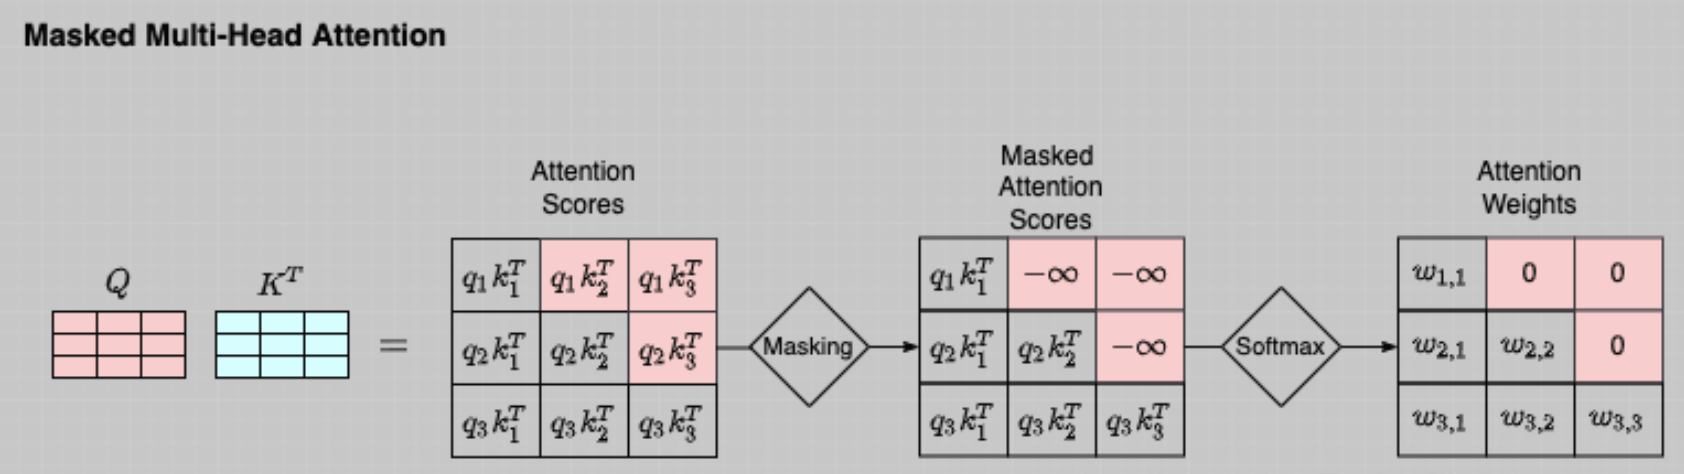

>- $Q = (q_1, q_2, ... , q_T)$: query 행렬
>- $K = (k_1, k_2, ... , k_T)$: key 행렬


### **Mask 생성**

> `True`는 attention이 적용될 부분, `False`는 masking될 위치이다.
>
>Padding을 맞출 필요는 없기 때문에 padding token에 mask를 `False`로 설정한다.

In [24]:
'''
batch != pad_id 를 통해서 pad_id인 부분은 False가 되고,
향후 (B, L, L)과 곱하기 위해서 (B, 1, L)로
두번째 차원을 unsqueeze 함
'''

padding_mask = (batch != pad_id).unsqueeze(1)  # (B, 1, L)

print(padding_mask)
print(padding_mask.shape)

tensor([[[ True,  True,  True,  True,  True,  True,  True,  True, False, False]],

        [[ True,  True,  True,  True,  True, False, False, False, False, False]],

        [[ True,  True,  True,  True,  True,  True,  True,  True,  True,  True]],

        [[ True,  True,  True,  True, False, False, False, False, False, False]],

        [[ True,  True,  True,  True,  True,  True,  True,  True,  True, False]]])
torch.Size([5, 1, 10])



>`torch.tril` 함수를 통해 lower triangle 행렬을 생성해 subsequent token mask로 사용할 수 있다.

In [25]:
'''
(1, L, L) 크기의 전부 1로 채워진 행렬을 만든 후
tril (triangle lower) 함수를 통해서
lower triangle 행렬을 생성
'''

nopeak_mask = torch.ones([1, max_len, max_len], dtype=torch.bool)  # (1, L, L)
nopeak_mask = torch.tril(nopeak_mask)  # (1, L, L)

print(nopeak_mask)
print(nopeak_mask.shape)

tensor([[[ True, False, False, False, False, False, False, False, False, False],
         [ True,  True, False, False, False, False, False, False, False, False],
         [ True,  True,  True, False, False, False, False, False, False, False],
         [ True,  True,  True,  True, False, False, False, False, False, False],
         [ True,  True,  True,  True,  True, False, False, False, False, False],
         [ True,  True,  True,  True,  True,  True, False, False, False, False],
         [ True,  True,  True,  True,  True,  True,  True, False, False, False],
         [ True,  True,  True,  True,  True,  True,  True,  True, False, False],
         [ True,  True,  True,  True,  True,  True,  True,  True,  True, False],
         [ True,  True,  True,  True,  True,  True,  True,  True,  True,  True]]])
torch.Size([1, 10, 10])


In [26]:
'''
pad_id는 False로 처리하는 padding_mask와
대각선 윗부분은 False로 처리하는 nopeak_mask를
& 연산하여 최종 mask 생성

여기에서 (B, 1, L) shape인 padding_mask를
(B, L, L) shape인 nopeak_mask와 & 연산하게 되면
두번째 차원에 대해서 broadcasting이 일어남
'''

mask = padding_mask & nopeak_mask  # (B, L, L)

print(mask)
print(mask.shape)

tensor([[[ True, False, False, False, False, False, False, False, False, False],
         [ True,  True, False, False, False, False, False, False, False, False],
         [ True,  True,  True, False, False, False, False, False, False, False],
         [ True,  True,  True,  True, False, False, False, False, False, False],
         [ True,  True,  True,  True,  True, False, False, False, False, False],
         [ True,  True,  True,  True,  True,  True, False, False, False, False],
         [ True,  True,  True,  True,  True,  True,  True, False, False, False],
         [ True,  True,  True,  True,  True,  True,  True,  True, False, False],
         [ True,  True,  True,  True,  True,  True,  True,  True, False, False],
         [ True,  True,  True,  True,  True,  True,  True,  True, False, False]],

        [[ True, False, False, False, False, False, False, False, False, False],
         [ True,  True, False, False, False, False, False, False, False, False],
         [ True,  True,  T

>0번 batch의 mask를 시각화해보자.

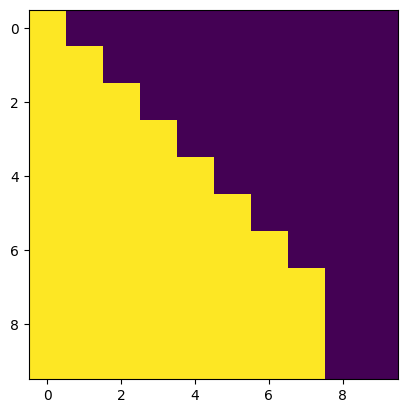

In [27]:
plt.imshow(mask[0])

### **Linear transformation & 여러 head로 나누기**

In [28]:
w_q = nn.Linear(d_model, d_model)
w_k = nn.Linear(d_model, d_model)
w_v = nn.Linear(d_model, d_model)

w_0 = nn.Linear(d_model, d_model)

In [29]:
q = w_q(batch_emb)  # (B, L, d_model)
k = w_k(batch_emb)  # (B, L, d_model)
v = w_v(batch_emb)  # (B, L, d_model)

batch_size = q.shape[0]
d_k = d_model // num_heads

q = q.view(batch_size, -1, num_heads, d_k)  # (B, L, num_heads, d_k)
k = k.view(batch_size, -1, num_heads, d_k)  # (B, L, num_heads, d_k)
v = v.view(batch_size, -1, num_heads, d_k)  # (B, L, num_heads, d_k)

q = q.transpose(1, 2)  # (B, num_heads, L, d_k)
k = k.transpose(1, 2)  # (B, num_heads, L, d_k)
v = v.transpose(1, 2)  # (B, num_heads, L, d_k)

print(q.shape)
print(k.shape)
print(v.shape)

torch.Size([5, 8, 10, 64])
torch.Size([5, 8, 10, 64])
torch.Size([5, 8, 10, 64])


### **Masking이 적용된 self-attention 구현**

> `tensor.masked_fill(masks, value)` 함수를 통해 `masks=True`인 위치에 value 값을 채워넣을 수 있다.

In [30]:
attn_scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(d_k)  # (B, num_heads, L, L)

In [31]:
'''
(B, L, L)인 mask를
multi-head에 적용하기 위해서 두번째 차원을 unsqueeze
'''

masks = mask.unsqueeze(1)  # (B, 1, L, L)


'''
masked_fill_ 함수를 통해서
masks가 False인 위치에는
-1 * torch.inf 값이 대입됨
'''
masked_attn_scores = attn_scores.masked_fill_(masks == False, -1 * torch.inf)  # (B, num_heads, L, L)

print(f'masks: {masks[0][0]}\n')
print(f'masked attention: {masked_attn_scores[0][0]}\n')
print(f'masked attention shape: {masked_attn_scores.shape}')

masks: tensor([[ True, False, False, False, False, False, False, False, False, False],
        [ True,  True, False, False, False, False, False, False, False, False],
        [ True,  True,  True, False, False, False, False, False, False, False],
        [ True,  True,  True,  True, False, False, False, False, False, False],
        [ True,  True,  True,  True,  True, False, False, False, False, False],
        [ True,  True,  True,  True,  True,  True, False, False, False, False],
        [ True,  True,  True,  True,  True,  True,  True, False, False, False],
        [ True,  True,  True,  True,  True,  True,  True,  True, False, False],
        [ True,  True,  True,  True,  True,  True,  True,  True, False, False],
        [ True,  True,  True,  True,  True,  True,  True,  True, False, False]])

masked attention: tensor([[-0.1517,    -inf,    -inf,    -inf,    -inf,    -inf,    -inf,    -inf,
            -inf,    -inf],
        [ 0.0493,  0.4471,    -inf,    -inf,    -inf,    -inf,  

> `-1* torch.inf`로 masking된 부분은 softmax 후 0이 된다.

In [32]:
attn_dists = F.softmax(masked_attn_scores, dim=-1)  # (B, num_heads, L, L)

print(f'masked attention distribution: {attn_dists[0][0]}\n')
print(attn_dists.shape)

masked attention distribution: tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.4018, 0.5982, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.3861, 0.2995, 0.3144, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.3669, 0.1978, 0.1726, 0.2627, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.1825, 0.1070, 0.2122, 0.3227, 0.1756, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.1487, 0.1012, 0.1956, 0.1578, 0.2927, 0.1041, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.1481, 0.2047, 0.1981, 0.0936, 0.1331, 0.1400, 0.0824, 0.0000, 0.0000,
         0.0000],
        [0.1160, 0.1727, 0.1233, 0.1584, 0.0549, 0.0803, 0.1217, 0.1727, 0.0000,
         0.0000],
        [0.0772, 0.0921, 0.1572, 0.1000, 0.1535, 0.1738, 0.1542, 0.0921, 0.0000,
         0.0000],
        [0.0772, 0.0921, 0.1572, 0.1000, 0.1535, 0.1738, 0.1542, 0.0921, 0.000

In [33]:
attn_values = torch.matmul(attn_dists, v)  # (B, num_heads, L, d_k)

print(attn_values.shape)

torch.Size([5, 8, 10, 64])


### **Masking이 적용된 Multi-head Attention 모듈 코드**

In [34]:
class MultiheadAttention(nn.Module):
  def __init__(self):
    super(MultiheadAttention, self).__init__()

    self.w_q = nn.Linear(d_model, d_model)
    self.w_k = nn.Linear(d_model, d_model)
    self.w_v = nn.Linear(d_model, d_model)

    # Linear transformation for concatenated outputs
    self.w_0 = nn.Linear(d_model, d_model)

  def forward(self, q, k, v, mask=None):
    batch_size = q.shape[0]

    q = self.w_q(q)  # (B, L, d_model)
    k = self.w_k(k)  # (B, L, d_model)
    v = self.w_v(v)  # (B, L, d_model)

    q = q.view(batch_size, -1, num_heads, d_k)  # (B, L, num_heads, d_k)
    k = k.view(batch_size, -1, num_heads, d_k)  # (B, L, num_heads, d_k)
    v = v.view(batch_size, -1, num_heads, d_k)  # (B, L, num_heads, d_k)

    q = q.transpose(1, 2)  # (B, num_heads, L, d_k)
    k = k.transpose(1, 2)  # (B, num_heads, L, d_k)
    v = v.transpose(1, 2)  # (B, num_heads, L, d_k)

    attn_values = self.self_attention(q, k, v, mask=mask)  # (B, num_heads, L, d_k)
    attn_values = attn_values.transpose(1, 2).contiguous().view(batch_size, -1, d_model)  # (B, L, num_heads, d_k) => (B, L, d_model)

    return self.w_0(attn_values)

  def self_attention(self, q, k, v, mask=None):
    attn_scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(d_k)  # (B, num_heads, L, L)

    '''
    mask를 인수로 받았을 경우에는
    masked_fill_ 함수 적용
    '''

    if mask is not None:
      mask = mask.unsqueeze(1)  # (B, 1, L, L) or  (B, 1, 1, L)
      attn_scores = attn_scores.masked_fill_(mask == False, -1*torch.inf)

    attn_dists = F.softmax(attn_scores, dim=-1)  # (B, num_heads, L, L)

    attn_values = torch.matmul(attn_dists, v)  # (B, num_heads, L, d_k)

    return attn_values

In [35]:
multihead_attn = MultiheadAttention()

outputs = multihead_attn(batch_emb, batch_emb, batch_emb, mask=mask)  # (B, L, d_model)

In [36]:
print(outputs)
print(outputs.shape)

tensor([[[ 0.3865, -0.1067,  0.3965,  ..., -0.6077, -0.0150, -0.1446],
         [ 0.0800, -0.2747,  0.1897,  ..., -0.1492, -0.2443, -0.0153],
         [ 0.2134, -0.1289, -0.0238,  ..., -0.1404, -0.2066, -0.1431],
         ...,
         [-0.0043, -0.0071,  0.0310,  ...,  0.0622, -0.1363, -0.0901],
         [-0.0482, -0.0109, -0.0304,  ...,  0.0975, -0.1246, -0.0723],
         [-0.0482, -0.0109, -0.0304,  ...,  0.0975, -0.1246, -0.0723]],

        [[-0.7594,  0.1923, -0.4304,  ..., -0.2295,  0.1840,  0.2264],
         [-0.3017, -0.1577, -0.2011,  ..., -0.1658,  0.2735,  0.2780],
         [-0.0695,  0.0632, -0.3106,  ..., -0.1511,  0.1767,  0.3253],
         ...,
         [ 0.0285, -0.0148, -0.3153,  ...,  0.0774,  0.0658,  0.1161],
         [ 0.0285, -0.0148, -0.3153,  ...,  0.0774,  0.0658,  0.1161],
         [ 0.0285, -0.0148, -0.3153,  ...,  0.0774,  0.0658,  0.1161]],

        [[ 0.1019, -0.2132, -0.2107,  ..., -0.6236,  0.0122,  0.2278],
         [ 0.1275, -0.0839, -0.1108,  ..., -0

## 4. **Decoder Attention**

>Transformer는 이전 단원에서 학습한 Seq2Seq 모델과 같이 Encoder-Decoder 구조로 이루어져있다.
>
> Query, key, value가 같은 sequence에서 생성될 경우 이를 self-attention이라고 부른다.
>
>Encoder-Decoder 구조에서 encoder의 경우 self-attention을 사용하지만, decoder는 encoder에서 압축된 정보와 더불어 RNN과 비슷하게 이전 스텝에 생성된 문장에 대한 정보가 함께 들어가야 한다.
>
>이 경우, key와 value는 source sequence로부터, query는 target sequence로부터 생성한다.
>
>Decoder에 들어갈 target sequence를 새로 선언한 후 Decoder에서 사용되는 Multi-head Attention을 구현해보자.

In [37]:
# 디코더에 입력될 trg_data

trg_data = [
  [33, 11, 49, 10],
  [88, 34, 5, 29, 99, 45, 11, 25],
  [67, 25, 15, 90, 54, 4, 92, 10, 46, 20, 88 ,19],
  [16, 58, 91, 47, 12, 5, 8],
  [71, 63, 62, 7, 9, 11, 55, 91, 32, 48]
]

trg_data, trg_max_len = padding(trg_data)

Maximum sequence length: 12


100%|██████████| 5/5 [00:00<00:00, 56679.78it/s]


In [38]:
# S_L: source maximum sequence length, T_L: target maximum sequence length
src_batch = batch  # (B, S_L)
trg_batch = torch.LongTensor(trg_data)  # (B, T_L)

print(src_batch.shape)
print(trg_batch.shape)

torch.Size([5, 10])
torch.Size([5, 12])


In [39]:
'''
source와 target 시퀀스를 임베딩으로 변환
'''

src_emb = embedding(src_batch)  # (B, S_L, d_w)
trg_emb = embedding(trg_batch)  # (B, T_L, d_w)

print(src_emb.shape)
print(trg_emb.shape)

torch.Size([5, 10, 512])
torch.Size([5, 12, 512])


> `src_emb`를 encoder에서 나온 결과, 그리고 `trg_emb`를 masked multi-head attention 후 결과로 가정한다.

In [40]:
# Query에는 trg_emb가 입력으로
q = w_q(trg_emb)  # (B, T_L, d_model)

# Key, Value에는 src_emb가 입력으로
k = w_k(src_emb)  # (B, S_L, d_model)
v = w_v(src_emb)  # (B, S_L, d_model)

batch_size = q.shape[0]
d_k = d_model // num_heads

q = q.view(batch_size, -1, num_heads, d_k)  # (B, T_L, num_heads, d_k)
k = k.view(batch_size, -1, num_heads, d_k)  # (B, S_L, num_heads, d_k)
v = v.view(batch_size, -1, num_heads, d_k)  # (B, S_L, num_heads, d_k)

q = q.transpose(1, 2)  # (B, num_heads, T_L, d_k)
k = k.transpose(1, 2)  # (B, num_heads, S_L, d_k)
v = v.transpose(1, 2)  # (B, num_heads, S_L, d_k)

print(q.shape)
print(k.shape)
print(v.shape)

torch.Size([5, 8, 12, 64])
torch.Size([5, 8, 10, 64])
torch.Size([5, 8, 10, 64])


In [41]:
attn_scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(d_k)  # (B, num_heads, T_L, S_L)
attn_dists = F.softmax(attn_scores, dim=-1)  # (B, num_heads, T_L, S_L)

print(attn_dists.shape)

torch.Size([5, 8, 12, 10])


In [42]:
attn_values = torch.matmul(attn_dists, v)  # (B, num_heads, T_L, d_k)

print(attn_values.shape)

torch.Size([5, 8, 12, 64])


## 5. Transformer 구현

> 위에서 학습한 내용을 바탕으로 실제 transformer 모델을 구현해보자.
>
>Transformer 모델은 encoder-decoder 구조를 가지고 있다.
>
>다만 RNN 대신 multi-head Attention block과 residual layer로 구성되어 있으며, 일반적으로 사용하는 batch normalization 대신 layer normalization을, ReLU 대신 GeLU activation을 사용한다는 특징이 있다.

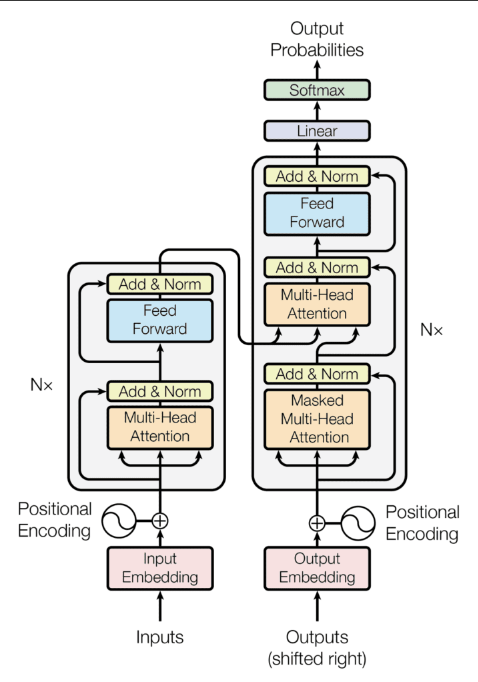

>Multi-head Attention에서 head dimension을 나누고 병합할 때 많이 쓰이는 shape 변환 함수를 선언해두자.

In [43]:
def split_last(x, shape):
    """
    x의 마지막 차원을 주어진 shape 형태로 나누는 함수
    예: [batch, seq_len, hidden] -> [batch, seq_len, num_heads, head_dim]
    """

    # shape을 수정할 수 있도록 리스트로 변환
    shape = list(shape)

    # shape 안에 -1은 최대 1개까지만 허용
    # -1은 PyTorch view에서처럼 "자동으로 계산할 차원"을 의미
    assert shape.count(-1) <= 1

    # shape 안에 -1이 있는 경우 자동으로 차원 크기를 계산
    if -1 in shape:

        # x.size(-1)
        # → 입력 텐서의 마지막 차원 크기
        #
        # 예:
        # x.shape = [32, 128, 768]
        # x.size(-1) = 768

        # np.prod(shape)
        # → shape 원소들의 곱
        #
        # 예:
        # shape = [12, -1]
        # np.prod(shape) = -12

        # -np.prod(shape)
        # → -(-12) = 12
        #
        # 즉 이미 알고 있는 차원들의 곱

        # 768 / 12 = 64
        #
        # 따라서
        # shape = [12, 64]
        #
        # 가 되도록 -1 자리에 들어갈 값을 계산

        shape[shape.index(-1)] = int(
            x.size(-1) / -np.prod(shape)
        )

    # x의 기존 차원 중 마지막 차원을 제외한 부분은 그대로 유지하고,
    # 마지막 차원만 shape 형태로 나누어 새로운 차원들로 분리
    #
    # 예:
    # x.shape = [32, 128, 768]
    # shape = [12, 64]
    #
    # x.size()[:-1]
    # → 마지막 차원 768을 제외한 앞쪽 차원
    # → [32, 128]
    #
    # *x.size()[:-1]
    # → 32, 128 처럼 풀어서 전달
    #
    # *shape
    # → 12, 64 처럼 풀어서 전달
    #
    # 따라서 아래 코드는
    # x.view(32, 128, 12, 64)
    # 와 같은 의미
    #
    # 결과:
    # [32, 128, 768]
    # → [32, 128, 12, 64]
    return x.view(*x.size()[:-1], *shape)


def merge_last(x, n_dims):
    """
    x의 마지막 n_dims개의 차원을 하나의 차원으로 합치는 함수

    예:
    [batch, seq_len, num_heads, head_dim]
    → [batch, seq_len, hidden]
    """

    # x의 전체 shape을 가져옴
    #
    # 예:
    # x.shape = [32, 128, 12, 64]
    # s = [32, 128, 12, 64]
    s = x.size()

    # n_dims는 마지막에서 몇 개의 차원을 합칠지 의미함
    #
    # 예:
    # n_dims = 2
    # → 마지막 2개 차원인 12와 64를 합침
    #
    # n_dims > 1
    # → 최소 2개 이상의 차원을 합쳐야 함
    #
    # n_dims < len(s)
    # → 전체 차원을 전부 하나로 합치는 것은 허용하지 않음
    assert n_dims > 1 and n_dims < len(s)

    # s[:-n_dims]
    # → 마지막 n_dims개의 차원을 제외한 앞쪽 차원
    #
    # 예:
    # s = [32, 128, 12, 64]
    # n_dims = 2
    # s[:-2] = [32, 128]
    #
    # *s[:-n_dims]
    # → 32, 128 처럼 풀어서 전달
    #
    # -1
    # → 마지막 n_dims개의 차원을 하나로 합친 크기를
    #   PyTorch가 자동으로 계산하게 함
    #
    # 따라서 아래 코드는
    # x.view(32, 128, -1)
    # 와 같은 의미
    #
    # PyTorch가 -1을 자동 계산하면
    # 12 × 64 = 768
    #
    # 결과:
    # [32, 128, 12, 64]
    # → [32, 128, 768]
    return x.view(*s[:-n_dims], -1)

>위에서 학습한 padding을 추가해주는 연산을 함수화한다.

In [44]:
def get_attn_pad_mask(seq_q, seq_k):
    """
    Attention에서 PAD 토큰을 보지 못하게 막는 mask를 만드는 함수

    seq_q: Query 쪽 문장
    seq_k: Key 쪽 문장

    예:
    seq_k = [
        [5, 7, 9, 0, 0]
    ]

    여기서 0은 PAD 토큰이므로,
    attention 계산에서 0 위치를 가려야 함
    """

    # seq_q의 shape을 가져옴
    #
    # 예:
    # seq_q.shape = [batch_size, len_q]
    # seq_q.shape = [2, 5]
    batch_size, len_q = seq_q.size()

    # seq_k의 shape을 가져옴
    #
    # 예:
    # seq_k.shape = [batch_size, len_k]
    # seq_k.shape = [2, 5]
    batch_size, len_k = seq_k.size()

    # seq_k.data.eq(0)
    # → seq_k에서 값이 0인 위치를 True로 표시
    # → 0은 PAD 토큰이라고 가정
    #
    # 예:
    # seq_k = [[5, 7, 9, 0, 0]]
    #
    # seq_k.data.eq(0)
    # → [[False, False, False, True, True]]
    #
    # True인 위치는 attention에서 가릴 위치를 의미함
    pad_attn_mask = seq_k.data.eq(0).unsqueeze(1)

    # unsqueeze(1)
    # → 1번 차원에 새로운 차원을 추가
    #
    # 기존:
    # [batch_size, len_k]
    #
    # 변경:
    # [batch_size, 1, len_k]
    #
    # 예:
    # [[False, False, False, True, True]]
    #
    # →
    # [[[False, False, False, True, True]]]
    #
    # 이렇게 만드는 이유:
    # Query의 각 위치마다 동일한 PAD mask를 적용하기 위해서임

    # expand(batch_size, len_q, len_k)
    # → Query 길이 len_q만큼 mask를 복사해서 확장
    #
    # 기존 shape:
    # [batch_size, 1, len_k]
    #
    # 변경 shape:
    # [batch_size, len_q, len_k]
    #
    # 예:
    # len_q = 5, len_k = 5이면
    #
    # [
    #   [False, False, False, True, True],
    #   [False, False, False, True, True],
    #   [False, False, False, True, True],
    #   [False, False, False, True, True],
    #   [False, False, False, True, True]
    # ]
    #
    # 의미:
    # 모든 Query 위치에서 Key의 PAD 위치를 보지 못하게 함
    return pad_attn_mask.expand(batch_size, len_q, len_k)


def get_attn_subsequent_mask(seq):
    """
    Decoder self-attention에서 미래 토큰을 보지 못하게 막는 mask를 만드는 함수

    예:
    현재 위치가 2번째 토큰이면,
    3번째, 4번째, 5번째 토큰은 아직 보면 안 됨

    즉, Transformer Decoder의 masked self-attention에서 사용됨
    """

    # attention mask의 shape을 정의
    #
    # seq.shape = [batch_size, seq_len]
    #
    # attn_shape = [batch_size, seq_len, seq_len]
    #
    # 예:
    # seq.shape = [2, 5]
    # attn_shape = [2, 5, 5]
    attn_shape = [seq.size(0), seq.size(1), seq.size(1)]

    # np.ones(attn_shape)
    # → 전부 1로 채워진 배열을 만듦
    #
    # np.triu(..., k=1)
    # → 대각선 바로 위쪽부터 upper triangular 부분만 남김
    #
    # 예: seq_len = 5일 때
    #
    # [
    #   [0, 1, 1, 1, 1],
    #   [0, 0, 1, 1, 1],
    #   [0, 0, 0, 1, 1],
    #   [0, 0, 0, 0, 1],
    #   [0, 0, 0, 0, 0]
    # ]
    #
    # 여기서 1인 위치는 미래 토큰이므로 attention에서 가릴 위치
    subsequent_mask = np.triu(np.ones(attn_shape), k=1)

    # numpy 배열을 PyTorch tensor로 변환
    #
    # device=seq.device
    # → seq가 GPU에 있으면 mask도 GPU에 올리고,
    #   seq가 CPU에 있으면 mask도 CPU에 둠
    #
    # .byte()
    # → mask로 사용할 수 있도록 0/1 값을 byte 타입으로 변환
    subsequent_mask = torch.tensor(subsequent_mask, device=seq.device).byte()

    # 결과 shape:
    # [batch_size, seq_len, seq_len]
    #
    # 의미:
    # 각 위치가 자기보다 뒤에 있는 미래 위치를 보지 못하게 함
    return subsequent_mask

### **예시 데이터 생성**

In [45]:
sample_input = torch.tensor([[  101,  2572,  3217,  5831,  5496,  2010,  2567,  1010,  3183,  2002,
         2170,  1000,  1996,  7409,  1000,  1010,  1997,  9969,  4487, 23809,
         3436,  2010,  3350,  1012,   102,  7727,  2000,  2032,  2004,  2069,
         1000,  1996,  7409,  1000,  1010,  2572,  3217,  5831,  5496,  2010,
         2567,  1997,  9969,  4487, 23809,  3436,  2010,  3350,  1012,   102,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0]])



sample = [sample_input]

>실제 Transformer model에서 사용하는 configuration 을 선언해보자.

In [46]:
sample_config = {
    "dim": 768,
    "dim_ff": 3072,
    "n_layers": 12,
    "p_drop_attn": 0.1,
    "n_heads": 12,
    "p_drop_hidden": 0.1,
    "max_len": 512,
    "n_segments": 2,
    "vocab_size": 30522
}


class AttributeDict(dict):
    """
    dict를 상속받아 만든 클래스

    원래 dict는 다음처럼 key로 접근함

    config["dim"]

    그런데 이 클래스는 다음처럼
    속성처럼 보이는 방식으로도 접근할 수 있게 해줌

    config.dim

    단, 실제로 dim이라는 속성이 만들어진 것은 아님
    내부적으로는 여전히 dict의 key인 "dim"을 찾는 것임
    """

    def __getattr__(self, name):
        """
        객체에 실제 속성으로 존재하지 않는 이름에 접근했을 때 호출됨

        예:

        model_config.dim

        을 실행하면 Python은 먼저
        model_config 객체 안에 dim이라는 실제 속성이 있는지 찾음

        하지만 dim은 실제 속성이 아니라
        dict 안의 key임

        그래서 Python은 __getattr__(self, "dim")을 호출함

        여기서 name = "dim" 이 되고,
        self["dim"]을 반환함

        즉,

        model_config.dim
        ↓
        __getattr__("dim")
        ↓
        self["dim"]
        ↓
        768

        처럼 동작함
        """
        return self[name]


# 일반 dict를 AttributeDict 객체로 감쌈
model_config = AttributeDict(sample_config)

# 아래 두 코드는 같은 결과를 냄
#
# model_config["dim"]
# model_config.dim
#
# 단, model_config.dim은 실제 속성 dim이 있는 것이 아니라
# __getattr__이 "dim"이라는 key를 찾아서 반환해주는 것임

In [47]:
sample_input.size()

torch.Size([1, 128])

### **Activation function**

> Activation Function으로 사용할 GeLU를 구현한다.

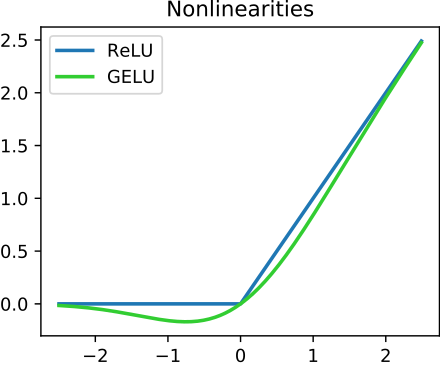

In [48]:
def gelu(x):
    """
    GELU(Gaussian Error Linear Unit) 활성화 함수

    GELU는 다음 수식을 구현한 것임

    GELU(x) = x Φ(x)

    여기서 Φ(x)는 표준정규분포의 누적분포함수(CDF)

    즉,
    입력 x를 무조건 통과시키는 것이 아니라

    "표준정규분포에서 x 이하가 나올 확률"

    만큼만 통과시키는 방식임

    따라서

    x가 매우 크면
    → Φ(x) ≈ 1
    → 거의 그대로 통과

    x가 매우 작으면
    → Φ(x) ≈ 0
    → 거의 제거

    x가 0 근처이면
    → 일부만 통과

    하는 부드러운 활성화 함수가 됨
    """

    # 표준정규분포의 CDF Φ(x)는 직접 계산하기 어렵기 때문에
    # Error Function(erf)을 이용하여 계산함
    #
    # Φ(x)
    # =
    # 0.5 * (1 + erf(x / √2))
    #
    # -----------------------------------------
    # 왜 x를 √2로 나누는가?
    # -----------------------------------------
    #
    # 표준정규분포 CDF에는
    #
    #     exp(-t²/2)
    #
    # 가 등장하지만,
    #
    # erf의 정의에는
    #
    #     exp(-u²)
    #
    # 가 등장함
    #
    # 따라서
    #
    #     u = t / √2
    #
    # 라는 변수 치환을 통해
    #
    #     exp(-t²/2)
    #     ↓
    #     exp(-u²)
    #
    # 형태로 변환할 수 있음
    #
    # 그래서 erf 안에 x/√2가 들어감

    # -----------------------------------------
    # 왜 1을 더하는가?
    # -----------------------------------------
    #
    # erf의 출력 범위는
    #
    #     [-1, 1]
    #
    # 임
    #
    # 하지만 확률(CDF)은
    #
    #     [0, 1]
    #
    # 범위여야 함
    #
    # 따라서
    #
    #     erf(x/√2)
    #
    # 에 1을 더하여
    #
    #     [0, 2]
    #
    # 범위로 이동시킴

    # -----------------------------------------
    # 왜 0.5를 곱하는가?
    # -----------------------------------------
    #
    # 현재 범위가
    #
    #     [0, 2]
    #
    # 이므로
    #
    # 0.5를 곱하여
    #
    #     [0, 1]
    #
    # 범위로 다시 스케일링함
    #
    # 결과적으로
    #
    #     0.5 * (1 + erf(x/√2))
    #
    # 는 정확히
    #
    #     Φ(x)
    #
    # 즉 표준정규분포의 CDF가 됨

    # GELU(x) = x * Φ(x)
    return x * 0.5 * (1.0 + torch.erf(x / math.sqrt(2.0)))

### **Layer normalization**

> Transformer에서 사용할 Layer Normalization을 직접 구현한다.
>
>Mini-batch에 따라, 그리고 문장의 길이에 따라 결과가 달라지는 Batch Normalization 보다는 그에 무관하게 각각의 token feature를 정규화하는 Layer Normalization 기법이 sequence를 다루는 정규화 기법으로 알맞다.

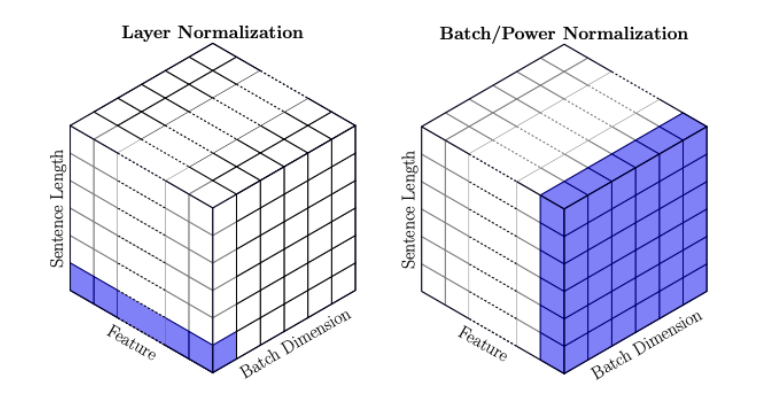

In [49]:
class LayerNorm(nn.Module):
    def __init__(self, cfg, variance_epsilon=1e-12):
        super().__init__()

        # LayerNorm 이후 각 특성(feature)에 대해
        # 곱해줄 스케일 파라미터 γ(gamma)
        #
        # 초기값은 모두 1
        #
        # shape:
        # [hidden_size]
        #
        # 예:
        # cfg.dim = 768
        # → gamma.shape = [768]
        #
        # 학습 과정에서 최적의 스케일 값으로 업데이트됨
        self.gamma = nn.Parameter(torch.ones(cfg.dim))

        # LayerNorm 이후 각 특성(feature)에 대해
        # 더해줄 이동 파라미터 β(beta)
        #
        # 초기값은 모두 0
        #
        # shape:
        # [hidden_size]
        #
        # 학습 과정에서 최적의 이동 값으로 업데이트됨
        self.beta = nn.Parameter(torch.zeros(cfg.dim))

        # 분산이 0에 가까운 경우
        # sqrt(0) 또는 0으로 나누는 문제를 방지하기 위한 작은 값
        self.variance_epsilon = variance_epsilon

    def forward(self, x):

        # ----------------------------------
        # 1. 평균 계산
        # ----------------------------------
        #
        # x.shape 예시
        #
        # [batch_size, seq_len, hidden_size]
        #
        # 예:
        # [32, 128, 768]
        #
        # 마지막 차원(hidden_size)에 대해 평균 계산
        #
        # 즉 각 토큰마다
        #
        # [768개 특성]
        #
        # 의 평균을 구함
        #
        # keepdim=True
        # → 차원을 유지
        #
        # 결과 shape:
        # [32, 128, 1]
        #
        u = x.mean(-1, keepdim=True)

        # ----------------------------------
        # 2. 분산 계산
        # ----------------------------------
        #
        # (x - u)
        # → 평균을 뺀 값
        #
        # .pow(2)
        # → 제곱
        #
        # .mean(...)
        # → 평균
        #
        # 즉
        #
        # Var(x)
        # =
        # E[(x - mean)^2]
        #
        # 을 계산
        #
        # 결과 shape:
        # [32, 128, 1]
        #
        s = (x - u).pow(2).mean(-1, keepdim=True)

        # ----------------------------------
        # 3. 정규화
        # ----------------------------------
        #
        # sqrt(variance)
        # → 표준편차(std)
        #
        # 따라서
        #
        # (x - mean) / std
        #
        # 를 계산
        #
        # 결과적으로 각 토큰의 특성 벡터가
        #
        # 평균 = 0
        # 분산 = 1
        #
        # 이 되도록 정규화됨
        #
        x = (x - u) / torch.sqrt(s + self.variance_epsilon)

        # ----------------------------------
        # 4. 학습 가능한 스케일 및 이동
        # ----------------------------------
        #
        # LayerNorm만 수행하면
        #
        # 평균 = 0
        # 분산 = 1
        #
        # 으로 강제됨
        #
        # 하지만 이것이 항상 최적인 것은 아니므로
        #
        # γ(gamma)
        # → 스케일 조정
        #
        # β(beta)
        # → 위치 이동
        #
        # 을 학습하도록 함
        #
        # 최종 식
        #
        # y = γx + β
        #
        # 여기서 γ, β는 학습 가능한 파라미터
        #
        return self.gamma * x + self.beta

### **Module1 - Embedding Layer**

>같은 단어의 경우에도 문장 안에서의 위치에 따라 다른 의미를 가지고 있을 수 있다.
>
>RNN의 경우 문장을 순서대로 입력하기 때문에 그 자체로 token의 위치 정보가 담길 수 있지만, transformer 모델에서는 각 token의 위치를 표현해줄 수 있는 수단이 없다.
>
>따라서 sin, cos 함수를 이용해서 위치를 표현해주는 positional embedding vector를 생성해 token의 embedding vector에 더해준다.

>예시로 3차원의 positional embedding layer를 구현해보자.

In [50]:
def get_sinusoid_encoding_table(n_position, d_model):
    """
    Sinusoidal Position Encoding Table을 만드는 함수

    Transformer의 위치 인코딩은 단어의 순서 정보를 모델에 알려주기 위해 사용됨

    n_position:
    → 만들 위치 개수
    → 예: 문장 길이가 10이면 0번 위치부터 9번 위치까지 만듦

    d_model:
    → 각 위치 벡터의 차원 수
    → 예: d_model = 3이면 각 위치는 3차원 벡터로 표현됨
    """

    def cal_angle(position, hid_idx):
        """
        특정 position과 특정 차원 hid_idx에 대한 angle 값을 계산

        position:
        → 토큰의 위치

        hid_idx:
        → 위치 벡터 안에서 몇 번째 차원인지

        hid_idx // 2를 사용하는 이유:
        → 짝수 차원과 바로 다음 홀수 차원이 같은 주파수를 공유하기 때문

        예:
        hid_idx = 0, 1 → 같은 주파수
        hid_idx = 2, 3 → 같은 주파수
        """
        return position / np.power(10000, 2 * (hid_idx // 2) / d_model)

    def get_posi_angle_vec(position):
        """
        하나의 position에 대해
        d_model개 차원의 angle 값을 모두 계산

        예:
        d_model = 3이면

        [
            cal_angle(position, 0),
            cal_angle(position, 1),
            cal_angle(position, 2)
        ]

        형태의 리스트를 만듦
        """
        return [cal_angle(position, hid_j) for hid_j in range(d_model)]

    # 모든 position에 대해 angle vector를 생성
    #
    # 예:
    # n_position = 10
    # d_model = 3
    #
    # position 0 → [angle_0, angle_1, angle_2]
    # position 1 → [angle_0, angle_1, angle_2]
    # ...
    # position 9 → [angle_0, angle_1, angle_2]
    #
    # 결과 shape:
    # [n_position, d_model]
    # 예: [10, 3]
    sinusoid_table = np.array(
        [get_posi_angle_vec(pos_i) for pos_i in range(n_position)]
    )

    # 짝수 번째 차원에는 sin 적용
    #
    # 0::2
    # → 0번 차원부터 시작해서 2칸씩 건너뜀
    # → 0, 2, 4, ...
    #
    # Transformer 원래 수식:
    # PE(pos, 2i) = sin(angle)
    sinusoid_table[:, 0::2] = np.sin(sinusoid_table[:, 0::2])

    # 홀수 번째 차원에는 cos 적용
    #
    # 1::2
    # → 1번 차원부터 시작해서 2칸씩 건너뜀
    # → 1, 3, 5, ...
    #
    # Transformer 원래 수식:
    # PE(pos, 2i+1) = cos(angle)
    sinusoid_table[:, 1::2] = np.cos(sinusoid_table[:, 1::2])

    # numpy 배열을 PyTorch FloatTensor로 변환하여 반환
    return torch.FloatTensor(sinusoid_table)


# 미리 계산된 sinusoidal position encoding table을 이용해
# Embedding layer를 생성
#
# get_sinusoid_encoding_table(10, 3)
# → shape: [10, 3]
# → 0번 위치부터 9번 위치까지의 3차원 위치 벡터
#
# nn.Embedding.from_pretrained(...)
# → 직접 학습하는 embedding이 아니라
#   미리 만들어진 embedding table을 사용하는 방식
#
# freeze=True
# → position embedding 값을 학습 중에 업데이트하지 않음
# → Transformer의 원래 sinusoidal position encoding처럼 고정된 위치 벡터로 사용
pos_embed = nn.Embedding.from_pretrained(
    get_sinusoid_encoding_table(10, 3),
    freeze=True
)

# 위치 index를 생성
#
# torch.arange(10)
# → [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
#
# dtype=torch.long
# → Embedding layer의 입력 index는 정수형이어야 하므로 long 타입 사용
#
# unsqueeze(0)
# → batch 차원을 추가
#
# 기존 shape:
# [10]
#
# 변경 shape:
# [1, 10]
#
# 의미:
# batch_size = 1
# seq_len = 10
pos = torch.arange(10, dtype=torch.long).unsqueeze(0)

print(f'input position: {pos}')

# pos_embed(pos)
# → 위치 index를 실제 positional embedding vector로 변환
#
# 입력 shape:
# [1, 10]
#
# 출력 shape:
# [1, 10, 3]
#
# 의미:
# batch_size = 1
# seq_len = 10
# d_model = 3
embedded = pos_embed(pos)

print(f'positional embeddings: {embedded}')

input position: tensor([[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]])
positional embeddings: tensor([[[ 0.0000,  1.0000,  0.0000],
         [ 0.8415,  0.5403,  0.0022],
         [ 0.9093, -0.4161,  0.0043],
         [ 0.1411, -0.9900,  0.0065],
         [-0.7568, -0.6536,  0.0086],
         [-0.9589,  0.2837,  0.0108],
         [-0.2794,  0.9602,  0.0129],
         [ 0.6570,  0.7539,  0.0151],
         [ 0.9894, -0.1455,  0.0172],
         [ 0.4121, -0.9111,  0.0194]]])


>이를 기반으로 Transformer embedding layer를 구현해보자.

In [51]:
class Embeddings(nn.Module):
    "The embedding module from word, position and token_type embeddings."

    def __init__(self, cfg):
        super().__init__()

        # 입력 token id를 dense vector로 변환
        self.tok_embed = nn.Embedding(cfg.vocab_size, cfg.dim)

        # 위치 정보를 나타내는 sinusoidal position embedding
        # freeze=True이므로 학습되지 않음
        self.pos_embed = nn.Embedding.from_pretrained(
            get_sinusoid_encoding_table(cfg.max_len, cfg.dim),
            freeze=True
        )

        # token embedding + position embedding 결과를 정규화
        self.norm = LayerNorm(cfg)

        # 과적합 방지를 위한 dropout
        self.drop = nn.Dropout(cfg.p_drop_hidden)

    def forward(self, x):
        # x.shape: [batch_size, seq_len]
        seq_len = x.size(1)

        # 각 token 위치 index 생성: [0, 1, 2, ..., seq_len-1]
        pos = torch.arange(seq_len, dtype=torch.long, device=x.device)

        # batch 크기에 맞게 position index 확장
        # [seq_len] -> [batch_size, seq_len]
        pos = pos.unsqueeze(0).expand_as(x)

        # token embedding과 position embedding을 더해 입력 표현 생성
        e = self.tok_embed(x) + self.pos_embed(pos)

        # LayerNorm 적용 후 Dropout 적용
        return self.drop(self.norm(e))

In [52]:
model = Embeddings(model_config)

In [53]:
out = model(sample[0])
out.size()

torch.Size([1, 128, 768])

### **Module2 - Multihead-Attention**

>위에서 학습한 multihead-attention module이다.
>
>Configuration을 입력으로 받을 수 있도록 코드를 수정한다.

In [54]:
class MultiHeadAttention(nn.Module):
    """ Multi-Headed Dot Product Attention """

    def __init__(self, cfg):
        super().__init__()

        # Query, Key, Value 생성용 선형 변환
        self.proj_q = nn.Linear(cfg.dim, cfg.dim)
        self.proj_k = nn.Linear(cfg.dim, cfg.dim)
        self.proj_v = nn.Linear(cfg.dim, cfg.dim)

        # Attention weight에 적용할 dropout
        self.drop = nn.Dropout(cfg.p_drop_attn)

        # Attention score 저장용
        self.scores = None

        # Attention head 개수
        self.n_heads = cfg.n_heads

    def forward(self, x, mask, x_q=None):
        """
        x: (B, S, D)
        mask: (B, S)

        B: batch size
        S: sequence length
        D: hidden dimension

        x_q가 None이면 Self-Attention,
        x_q가 있으면 Cross-Attention처럼 사용
        """

        # Query, Key, Value 생성
        if x_q is None:
            q, k, v = self.proj_q(x), self.proj_k(x), self.proj_v(x)
        else:
            q, k, v = self.proj_q(x_q), self.proj_k(x), self.proj_v(x)

        # Multi-Head 형태로 분리
        #
        # (B, S, D)
        # -> (B, S, H, W)
        # -> (B, H, S, W)
        #
        # H: head 개수
        # W: head 하나당 차원
        q, k, v = (
            split_last(x, (self.n_heads, -1)).transpose(1, 2)
            for x in [q, k, v]
        )

        # Query와 Key의 내적으로 attention score 계산
        #
        # q.shape: (B, H, S, W)
        # k.transpose(-2, -1).shape: (B, H, W, S)
        #
        # 결과 scores.shape:
        # (B, H, S, S)
        #
        # 마지막에 sqrt(W)로 나누어 score 크기를 안정화
        scores = q @ k.transpose(-2, -1) / np.sqrt(k.size(-1))

        # Padding 위치 마스킹
        if mask is not None:

            # mask.shape: (B, S)
            #
            # 예:
            # mask = [
            #   [1, 1, 1, 0, 0]
            # ]
            #
            # 여기서 1은 attention 가능 위치,
            # 0은 PAD라서 attention하면 안 되는 위치
            #
            # mask[:, None, :]
            # -> 중간에 head 차원 위치를 하나 추가
            #
            # (B, S)
            # -> (B, 1, S)
            #
            # 이렇게 하면 scores.shape인
            #
            # (B, H, S, S)
            #
            # 와 broadcasting이 가능해짐
            mask = mask[:, None, :].float()

            # 1.0 - mask
            #
            # mask가 1인 위치:
            # 1.0 - 1 = 0
            #
            # mask가 0인 위치:
            # 1.0 - 0 = 1
            #
            # 따라서 PAD 위치만 1이 됨
            #
            # torch.inf * (1.0 - mask)
            #
            # PAD가 아닌 위치:
            # inf * 0 = 0
            #
            # PAD 위치:
            # inf * 1 = inf
            #
            # scores에서 이 값을 빼면
            #
            # PAD가 아닌 위치:
            # score - 0 = 그대로
            #
            # PAD 위치:
            # score - inf = -inf
            #
            # 이후 softmax를 적용하면
            # -inf 위치의 확률은 0이 됨
            scores -= torch.inf * (1.0 - mask)

        # softmax로 attention weight 계산
        scores = self.drop(F.softmax(scores, dim=-1))

        # attention weight를 Value에 곱해 최종 context 계산
        #
        # scores.shape: (B, H, S, S)
        # v.shape:      (B, H, S, W)
        #
        # 결과:
        # (B, H, S, W)
        h = (scores @ v).transpose(1, 2).contiguous()

        # 여러 head를 다시 하나의 hidden vector로 합침
        #
        # (B, S, H, W)
        # -> (B, S, D)
        h = merge_last(h, 2)

        # attention weight 저장
        self.scores = scores

        return h

### **Module3- Base feedforward network**

In [55]:
class PositionWiseFeedForward(nn.Module):
    """ FeedForward Neural Networks for each position """
    def __init__(self, cfg):
        super().__init__()
        self.fc1 = nn.Linear(cfg.dim, cfg.dim_ff)
        self.fc2 = nn.Linear(cfg.dim_ff, cfg.dim)

    def forward(self, x):
        # (B, S, D) -> (B, S, D_ff) -> (B, S, D)
        return self.fc2(gelu(self.fc1(x)))

### **Transformer**

> 위에서 구현한 함수들을 활용하여, Transformer Encoder block과 Decoder block, 그리고 전체 모델을 구현한다.

In [56]:
class Encoder_Block(nn.Module):
    """ Transformer Encoder Block """

    def __init__(self, cfg):
        super().__init__()

        # Encoder self-attention
        self.attn = MultiHeadAttention(cfg)

        # attention 결과를 다시 hidden dim으로 변환
        self.proj = nn.Linear(cfg.dim, cfg.dim)

        # 첫 번째 Add & Norm
        self.norm1 = LayerNorm(cfg)

        # position-wise feed forward network
        self.pwff = PositionWiseFeedForward(cfg)

        # 두 번째 Add & Norm
        self.norm2 = LayerNorm(cfg)

        # dropout
        self.drop = nn.Dropout(cfg.p_drop_hidden)

    def forward(self, x, mask):
        # self-attention
        h = self.attn(x, mask)

        # attention 결과 + residual connection + layer norm
        h = self.norm1(x + self.drop(self.proj(h)))

        # feed forward + residual connection + layer norm
        h = self.norm2(h + self.drop(self.pwff(h)))

        return h


class Decoder_Block(nn.Module):
    """ Transformer Decoder Block """

    def __init__(self, cfg):
        super().__init__()

        # Decoder self-attention
        self.self_attention = MultiHeadAttention(cfg)

        # Encoder-Decoder attention
        self.encoder_attention = MultiHeadAttention(cfg)

        # self-attention 이후 Add & Norm
        self.norm1 = LayerNorm(cfg)
        self.proj1 = nn.Linear(cfg.dim, cfg.dim)

        # encoder-decoder attention 이후 Add & Norm
        self.norm2 = LayerNorm(cfg)
        self.proj2 = nn.Linear(cfg.dim, cfg.dim)

        # feed forward 이후 Add & Norm
        self.pwff = PositionWiseFeedForward(cfg)
        self.norm3 = LayerNorm(cfg)

        # dropout
        self.drop = nn.Dropout(cfg.p_drop_hidden)

    def forward(self, x, enc_outputs, dec_self_attn_mask, dec_enc_attn_mask):

        # masked self-attention
        h = self.self_attention(x, dec_self_attn_mask)
        h = self.norm1(x + self.drop(self.proj1(h)))

        # encoder-decoder attention
        h2 = self.encoder_attention(enc_outputs, dec_enc_attn_mask, x_q=h)
        h = self.norm2(h + self.drop(self.proj2(h2)))

        # feed forward
        h = self.norm3(h + self.drop(self.pwff(h)))

        return h


class Transformer(nn.Module):
    """ Encoder-Decoder Transformer """

    def __init__(self, cfg):
        super().__init__()

        # Encoder embedding
        self.encoder_embed = Embeddings(cfg)

        # Encoder block을 n_layers개 쌓음
        self.encoder_blocks = nn.ModuleList(
            [Encoder_Block(cfg) for _ in range(cfg.n_layers)]
        )

        # Decoder embedding
        self.decoder_embed = Embeddings(cfg)

        # Decoder block을 n_layers개 쌓음
        self.decoder_blocks = nn.ModuleList(
            [Decoder_Block(cfg) for _ in range(cfg.n_layers)]
        )

        # Decoder 출력 hidden vector를 vocab 크기로 변환
        self.projection = nn.Linear(cfg.dim, cfg.vocab_size)

    def forward(self, enc_inputs, dec_inputs):

        # ==================== Encoder ====================

        # encoder input embedding
        h = self.encoder_embed(enc_inputs)

        # encoder 입력의 PAD 위치 mask
        enc_self_attn_mask = get_attn_pad_mask(enc_inputs, enc_inputs)

        # encoder block 통과
        for block in self.encoder_blocks:
            h = block(h, enc_self_attn_mask)

        # 최종 encoder 출력
        enc_outputs = h

        # ==================== Decoder ====================

        # decoder PAD mask
        dec_self_attn_pad_mask = get_attn_pad_mask(dec_inputs, dec_inputs).float()

        # decoder 미래 토큰 mask
        dec_self_attn_subsequent_mask = get_attn_subsequent_mask(dec_inputs).float()

        # PAD mask와 subsequent mask를 합쳐 self-attention mask 생성
        #
        # dec_self_attn_pad_mask
        # → PAD 토큰 위치를 가리는 mask
        #
        # dec_self_attn_subsequent_mask
        # → 미래 토큰 위치를 가리는 mask
        #
        # 두 mask를 더하면,
        # PAD이거나 미래 토큰인 위치는 1 이상이 됨
        #
        # torch.gt(tensor, 0)
        # → tensor의 각 원소가 0보다 큰지 비교
        # → 0보다 크면 True
        # → 0보다 크지 않으면 False
        #
        # 즉, PAD 위치 또는 미래 토큰 위치를 True로 표시하는 mask를 만듦
        dec_self_attn_mask = torch.gt(
            dec_self_attn_pad_mask + dec_self_attn_subsequent_mask,
            0
        )

        # decoder가 encoder output을 볼 때 encoder의 PAD 위치를 가리는 mask
        dec_enc_attn_mask = get_attn_pad_mask(dec_inputs, enc_inputs)

        # decoder input embedding
        h = self.decoder_embed(dec_inputs)

        # decoder block 통과
        for block in self.decoder_blocks:
            h = block(h, enc_outputs, dec_self_attn_mask, dec_enc_attn_mask)

        # hidden vector를 vocab logits로 변환
        out = self.projection(h)

        return out

In [57]:
model = Transformer(model_config)
model.cuda()
out = model(sample[0].cuda(),sample[0].cuda())
out.size()

torch.Size([1, 128, 30522])